# 🦴 L4 Vertebra Detection & Bone Mineral Density Pipeline
## AP Pelvic X-ray DICOM → Spine Segmentation (U-Net) → L4 ROI → BMD Estimation

### 전체 파이프라인 구조
```
DICOM 파일
   │
   ▼
[Step 1] DICOM 로딩 & 메타데이터 추출
   │
   ▼
[Step 2] 이미지 전처리 (CLAHE 강화)
   │
   ▼
[Step 3] 척추 중심선 탐지 (분산×평균 컬럼 프로젝션)
   │
   ▼
[Step 4] 척추체 분리 (gradient 기반 경계 탐지)
          + 장골능(Iliac Crest) 랜드마크
   │
   ▼
[Step 5] L4 특정 (해부학적 위치 규칙)
   │
   ▼
[Step 6] U-Net 기반 척추 세그멘테이션
          (자체 학습 or 직접 데이터셋 훈련)
   │
   ▼
[Step 7] L4 ROI 경계 추출 & 시각화
   │
   ▼
[Step 8] BMD 추정 (ResNet-18 회귀 모델)
          + WHO T-Score 분류
   │
   ▼
[Step 9] 배치 처리 & CSV 리포트
```

> ⚠️ **임상 주의사항**: DEXA 장비가 아닌 일반 X-ray 기반 BMD 스크리닝입니다.  
> 골반 수술 환자의 추적 관찰(변화 측정)에 활용하며, 임상 진단은 방사선과 전문의 판독이 필요합니다.


## 📦 Step 0: 환경 설정 (패키지 설치)

In [1]:
import subprocess, sys

def install(pkg, extra_args=None):
    cmd = [sys.executable, '-m', 'pip', 'install', pkg,
           '--break-system-packages', '-q']
    if extra_args:
        cmd += extra_args
    subprocess.run(cmd, capture_output=True)

packages = [
    'pydicom', 'scikit-image', 'scipy', 'matplotlib',
    'numpy', 'pandas', 'tqdm', 'pillow', 'opencv-python-headless'
]
for p in packages:
    install(p)

# PyTorch (CPU version - GPU 있으면 cuda 버전으로 변경)
install('torch', ['--break-system-packages', '-q'])
install('torchvision', ['--break-system-packages', '-q'])

print("✅ All packages installed")


✅ All packages installed


In [2]:
import os, glob, json, warnings, csv
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

import pydicom
import cv2
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms

from skimage import exposure, filters, morphology, measure
from scipy.signal import find_peaks, savgol_filter
from scipy.ndimage import gaussian_filter

# ── 디바이스 설정 ──
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ 사용 디바이스: {DEVICE}")
print(f"   PyTorch: {torch.__version__}")

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 10


✅ 사용 디바이스: cpu
   PyTorch: 2.12.0+cpu


## ⚙️ Step 1: 경로 & 하이퍼파라미터 설정

In [3]:
# ══════════════════════════════════════════════════════
#   📁 경로 설정 - 사용자 환경에 맞게 수정하세요
# ══════════════════════════════════════════════════════

# 단일 파일 테스트용
DICOM_FILE = "./dataset-dcm/train/gather/1.2.826.0.1.3680043.8.498.11227155170490832168629184106125649390-c.dcm"

# 데이터셋 폴더 구조 (훈련/검증/테스트)
# 아래 구조를 사용하세요:
# DATASET_ROOT/
# ├── train/   ← 훈련 DICOM 파일들
# ├── val/     ← 검증 DICOM 파일들
# └── test/    ← 테스트 DICOM 파일들
DATASET_ROOT = "./dataset"
TRAIN_DIR    = os.path.join(DATASET_ROOT, "train")
VAL_DIR      = os.path.join(DATASET_ROOT, "val")
TEST_DIR     = os.path.join(DATASET_ROOT, "test")

# 레이블 파일 (옵션): CSV 형식으로 DXA 측정값 제공 시 지도학습 가능
# 컬럼: filename, t_score, bmd_gcm2 (없으면 비지도/프록시 학습)
LABEL_CSV    = "./dataset/labels.csv"          # DXA 레이블 있으면 경로 지정

# 출력 폴더
OUTPUT_DIR   = "./bmd_output"
MODEL_DIR    = os.path.join(OUTPUT_DIR, "models")
RESULT_DIR   = os.path.join(OUTPUT_DIR, "results")
for d in [OUTPUT_DIR, MODEL_DIR, RESULT_DIR]:
    os.makedirs(d, exist_ok=True)

# ══════════════════════════════════════════════════
#   🔧 모델 하이퍼파라미터
# ══════════════════════════════════════════════════
CFG = {
    # 이미지
    'img_size':        256,       # 입력 이미지 크기
    'roi_size':        64,        # L4 ROI 정규화 크기
    
    # 훈련
    'batch_size':      8,
    'num_epochs':      50,
    'lr':              1e-4,
    'weight_decay':    1e-4,
    'early_stop':      10,        # patience
    
    # 데이터 분할 (label CSV 없을 때 자동 분할)
    'train_ratio':     0.70,
    'val_ratio':       0.15,
    'test_ratio':      0.15,
    
    # BMD 기준값 (스캐너 phantom 교정 전 기본값)
    # ※ 실제 사용 시 phantom scan으로 calibration 필요
    'ref_young_mean':  19500.0,
    'ref_young_std':   1500.0,
    'ref_age_mean':    18500.0,
    'ref_age_std':     2000.0,
    
    # 척추 탐지 파라미터
    'spine_search_cx': (0.28, 0.60),   # X 탐색 범위 (이미지 너비 비율)
    'iliac_search_y':  (0.40, 0.60),   # 장골능 탐색 범위 (이미지 높이 비율)
    'strip_width':     30,              # 척추 strip 반폭 (px)
    'min_vert_dist':   12,              # 최소 척추체 간격 (px)
    'roi_width_ratio': 0.16,            # L4 ROI 폭 (이미지 너비 비율)
}

print("✅ 설정 완료")
print(f"   Dataset root : {DATASET_ROOT}")
print(f"   Output dir   : {OUTPUT_DIR}")
print(f"   Device       : {DEVICE}")
print(f"   Batch size   : {CFG['batch_size']}")


✅ 설정 완료
   Dataset root : ./dataset
   Output dir   : ./bmd_output
   Device       : cpu
   Batch size   : 8


## 📂 Step 2: DICOM 로딩 & 메타데이터 추출

In [4]:
def load_dicom(path):
    """
    DICOM 파일 로딩 및 임상 메타데이터 추출
    
    처리 항목:
    - Rescale Slope/Intercept 적용
    - MONOCHROME1 → 자동 반전 (뼈가 밝게)
    - 16-bit float 변환
    """
    try:
        dcm = pydicom.dcmread(path, force=True)
    except Exception as e:
        raise ValueError(f"DICOM 읽기 실패: {path} - {e}")
    
    arr = dcm.pixel_array.astype(np.float64)
    slope     = float(getattr(dcm, 'RescaleSlope',     1.0))
    intercept = float(getattr(dcm, 'RescaleIntercept', 0.0))
    arr       = arr * slope + intercept
    
    # MONOCHROME1: 뼈가 어둡게 나옴 → 반전
    photometric = getattr(dcm, 'PhotometricInterpretation', 'MONOCHROME2')
    if str(photometric).strip() == 'MONOCHROME1':
        arr = arr.max() - arr
    
    meta = {
        'patient_id'   : str(getattr(dcm, 'PatientID',            'Unknown')),
        'patient_age'  : str(getattr(dcm, 'PatientAge',           'Unknown')),
        'patient_sex'  : str(getattr(dcm, 'PatientSex',           'Unknown')),
        'modality'     : str(getattr(dcm, 'Modality',             'CR')),
        'study_date'   : str(getattr(dcm, 'StudyDate',            '')),
        'study_desc'   : str(getattr(dcm, 'StudyDescription',     '')),
        'institution'  : str(getattr(dcm, 'InstitutionName',      '')),
        'pixel_spacing': list(getattr(dcm, 'PixelSpacing',        [0.1, 0.1])),
        'kvp'          : str(getattr(dcm, 'KVP',                  'Unknown')),
        'shape'        : arr.shape,
        'filename'     : os.path.basename(path),
    }
    return arr, meta, dcm


# ── 샘플 파일 로딩 테스트 ──
arr, meta, dcm = load_dicom(DICOM_FILE)

print("=" * 52)
print("  DICOM 메타데이터")
print("=" * 52)
for k, v in meta.items():
    print(f"  {k:16s} : {v}")
print(f"  {'픽셀 범위':16s} : {arr.min():.0f} – {arr.max():.0f}")


  DICOM 메타데이터
  patient_id       : 1035
  patient_age      : 
  patient_sex      : 
  modality         : CR
  study_date       : 
  study_desc       : XRAY
  institution      : 
  pixel_spacing    : ['0.1', '0.1']
  kvp              : Unknown
  shape            : (256, 256)
  filename         : 1.2.826.0.1.3680043.8.498.11227155170490832168629184106125649390-c.dcm
  픽셀 범위            : 0 – 18081


## 🔬 Step 3: 이미지 전처리

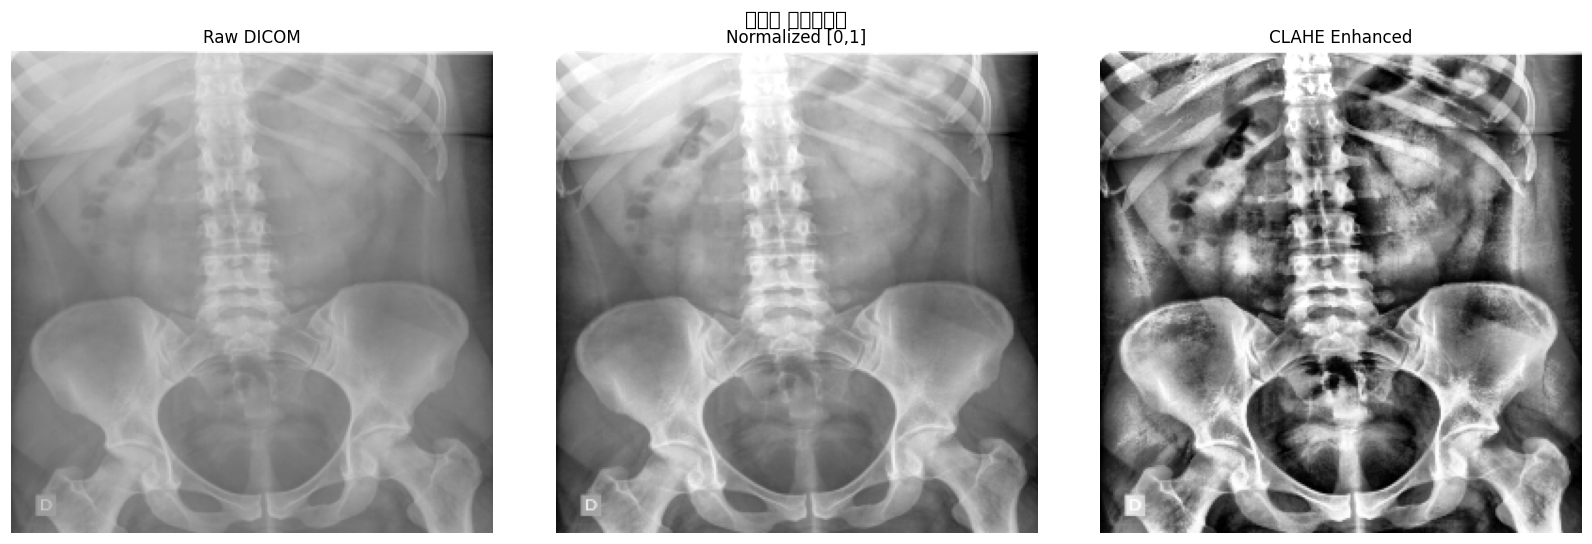

이미지 크기: 256x256 px | Pixel spacing: ['0.1', '0.1'] mm


In [5]:
def preprocess_xray(arr, target_size=256, clip_limit=0.04):
    """
    X-ray 전처리 파이프라인
    
    1. 정사각형 리사이즈 (패딩 유지)
    2. Min-max 정규화 → [0, 1]
    3. CLAHE 적용 (국소 대비 강화)
    """
    # 정사각형 패딩 리사이즈
    h, w   = arr.shape
    max_dim = max(h, w)
    padded  = np.zeros((max_dim, max_dim), dtype=arr.dtype)
    y_off   = (max_dim - h) // 2
    x_off   = (max_dim - w) // 2
    padded[y_off:y_off+h, x_off:x_off+w] = arr
    
    # 리사이즈
    resized = cv2.resize(padded, (target_size, target_size),
                         interpolation=cv2.INTER_LINEAR)
    
    # 정규화
    vmin, vmax = np.percentile(resized, [1, 99])
    norm = np.clip((resized - vmin) / (vmax - vmin + 1e-8), 0, 1)
    
    # CLAHE
    clahe = exposure.equalize_adapthist(norm, clip_limit=clip_limit)
    
    return norm, clahe, {'y_off': y_off, 'x_off': x_off,
                         'orig_shape': (h, w), 'max_dim': max_dim}


norm, clahe, pad_info = preprocess_xray(arr, target_size=CFG['img_size'])
h, w = clahe.shape

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
imgs   = [arr,  norm,  clahe]
titles = ['Raw DICOM', 'Normalized [0,1]', 'CLAHE Enhanced']
cmaps  = ['gray', 'gray', 'gray']
for ax, img, title, cmap in zip(axes, imgs, titles, cmaps):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=11)
    ax.axis('off')
plt.suptitle('전처리 파이프라인', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/01_preprocessing.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"이미지 크기: {h}x{w} px | Pixel spacing: {meta['pixel_spacing']} mm")


## 🎯 Step 4: 척추 탐지 & L4 위치 특정 (개선된 알고리즘)

In [6]:
# ────────────────────────────────────────────────
# 알고리즘 개선 포인트 (기존 대비)
# ────────────────────────────────────────────────
# 1. Spine X: 단순 mean → variancexmean 결합 스코어
#    → 척추의 고대비 수직 구조 더 정확히 탐지
# 2. 척추체 탐지: gradient 1차 미분 기반 boundary pair 매칭
#    → 밝기 피크 하나가 아닌 '상승→하강 경계쌍' = 실제 척추체
# 3. 장골능 탐지: row max값 기반 수평 구조 탐지
#    → 중앙 strip이 아닌 전체 이미지 폭에서 탐색
# 4. L4 특정: 장골능 직전 척추체 피크 선택 + 거리 기반 L4/L5 구분
# ────────────────────────────────────────────────

def detect_spine_x(clahe):
    """
    척추 중심 X 좌표 탐지
    분산(variance) x 평균(mean) 결합 스코어 → 수직 고대비 구조 탐지
    """
    h, w = clahe.shape
    upper = clahe[:int(h * 0.62), :]                  # 상위 62%만 사용
    score = savgol_filter(
        upper.mean(axis=0) * np.var(upper, axis=0),   # varxmean 결합
        window_length=11, polyorder=2
    )
    cx0 = int(w * CFG['spine_search_cx'][0])
    cx1 = int(w * CFG['spine_search_cx'][1])
    spine_x = int(np.argmax(score[cx0:cx1])) + cx0
    return spine_x, score


def detect_vertebrae_v5(clahe, spine_x):
    """
    척추체 탐지 (gradient boundary pair 방식)
    
    원리:
    - 척추 strip의 row 평균 강도 → 1차 미분
    - 상승 경계(disc→vert): d1 양수 peak
    - 하강 경계(vert→disc): d1 음수 peak  
    - 경계쌍 매칭 → 척추체 중심 계산
    """
    h, w = clahe.shape
    sw   = CFG['strip_width']
    sx1  = max(0, spine_x - sw)
    sx2  = min(w, spine_x + sw)
    strip = clahe[:int(h * 0.70), sx1:sx2]
    
    rp   = strip.mean(axis=1)
    rp_s = savgol_filter(rp, window_length=7, polyorder=2)
    d1   = savgol_filter(np.gradient(rp_s), window_length=5, polyorder=2)
    
    # 척추체 피크 탐지 (직접 방식)
    peaks,  _ = find_peaks( rp_s, distance=CFG['min_vert_dist'],
                             prominence=0.015, width=3)
    troughs, _ = find_peaks(-rp_s, distance=8, prominence=0.008)
    
    # gradient 경계쌍으로 척추체 boundary 계산
    b_up,   _ = find_peaks( d1, distance=5, prominence=0.004)
    b_down, _ = find_peaks(-d1, distance=5, prominence=0.004)
    
    vert_bounds = []  # (top, center, bottom) per vertebra
    for bu in b_up:
        after = b_down[b_down > bu]
        if len(after) == 0: continue
        bd  = after[0]
        gap = bd - bu
        if 6 <= gap <= 32:
            vert_bounds.append((int(bu), int((bu+bd)//2), int(bd)))
    
    return peaks, troughs, vert_bounds, rp_s, d1


def detect_iliac_crest(clahe):
    """
    장골능(Iliac Crest) 탐지
    
    장골능은 이미지 40-60% 구간에서 가로로 넓게 펼쳐진 고강도 구조.
    전체 폭에서 row_max 값이 가장 높은 위치 탐색.
    """
    h, w  = clahe.shape
    y0    = int(h * CFG['iliac_search_y'][0])
    y1    = int(h * CFG['iliac_search_y'][1])
    region = clahe[y0:y1, :]
    
    row_max = region.max(axis=1)           # 각 행의 최대값
    row_max_s = savgol_filter(row_max, 7, 2)
    
    peaks_idx, _ = find_peaks(row_max_s, distance=5, prominence=0.02)
    if len(peaks_idx) > 0:
        best = peaks_idx[np.argmax(row_max_s[peaks_idx])]
        iliac_row = int(best) + y0
    else:
        iliac_row = int(h * 0.48)         # fallback: 48%
    return iliac_row, row_max_s


def localize_l4_v5(peaks, vert_bounds, iliac_row, h, spine_x, w):
    """
    L4 척추체 위치 결정 (해부학적 랜드마크 기반)
    
    해부학적 기준 (AP Pelvis X-ray):
    ┌──────────────────────────────────┐
    │ T12/L1 ────────────── 상단 ~15% │
    │ L1  ───────────────── ~row  45  │
    │ L2  ───────────────── ~row  60  │
    │ L3  ───────────────── ~row  76  │
    │ L4  ── TARGET ──────── ~row  93  │ ← iliac crest - 15~25px
    │ L4/L5 disc ────────── ~row 106  │
    │ Iliac Crest ────────── ~row 122  │ ← 장골능
    │ L5/S1 ─────────────── ~row 130  │
    └──────────────────────────────────┘
    
    규칙:
    1. peaks에서 iliac_row 이하인 peak 후보군 선택
    2. 장골능과의 거리: 8px 미만이면 L5 (한 단계 위로)
    3. vert_bounds에서 해당 peak의 top/bottom 경계 사용
    """
    # 장골능 이하 peak 후보
    candidates = peaks[peaks < iliac_row + 8]
    
    if len(candidates) == 0:
        l4_ctr = max(0, iliac_row - 20)
    else:
        l4_ctr = int(candidates[-1])
        dist   = iliac_row - l4_ctr
        if dist < 8 and len(candidates) >= 2:
            l4_ctr = int(candidates[-2])   # L5→L4로 조정
    
    # vert_bounds에서 가장 가까운 경계 찾기
    if vert_bounds:
        dists = [abs(c - l4_ctr) for _, c, _ in vert_bounds]
        best  = vert_bounds[np.argmin(dists)]
        t, ctr, b = best
        # 최소 ROI 높이 보장
        margin = max(0, 10 - (b - t))
        t = max(0, t - margin)
        b = min(h, b + margin)
    else:
        pad = int(h * 0.06)
        t   = max(0, l4_ctr - pad)
        b   = min(h, l4_ctr + pad)
        ctr = l4_ctr
    
    rw   = int(w * CFG['roi_width_ratio'])
    x1   = max(0, spine_x - rw // 2)
    x2   = min(w, spine_x + rw // 2)
    
    return (t, ctr, b), (x1, x2)


# ── 탐지 실행 ──
spine_x,    col_score  = detect_spine_x(clahe)
peaks, troughs, vert_bounds, rp_s, d1 = detect_vertebrae_v5(clahe, spine_x)
iliac_row,  iliac_prof  = detect_iliac_crest(clahe)
(t_l4, l4_ctr, b_l4), (l4_x1, l4_x2) = localize_l4_v5(
    peaks, vert_bounds, iliac_row, h, spine_x, w)

print(f"✅ 척추 X 중심  : {spine_x}")
print(f"   장골능 Y     : {iliac_row}")
print(f"   척추 피크    : {peaks}")
print(f"   L4 중심 Y    : {l4_ctr}  (경계: {t_l4}~{b_l4})")
print(f"   L4 ROI       : y=[{t_l4}:{b_l4}], x=[{l4_x1}:{l4_x2}]")


✅ 척추 X 중심  : 74
   장골능 Y     : 133
   척추 피크    : [ 23  43  78 113 171]
   L4 중심 Y    : 113  (경계: 108~118)
   L4 ROI       : y=[108:118], x=[54:94]


## 🖼️ Step 5: L4 ROI 추출 & 시각화

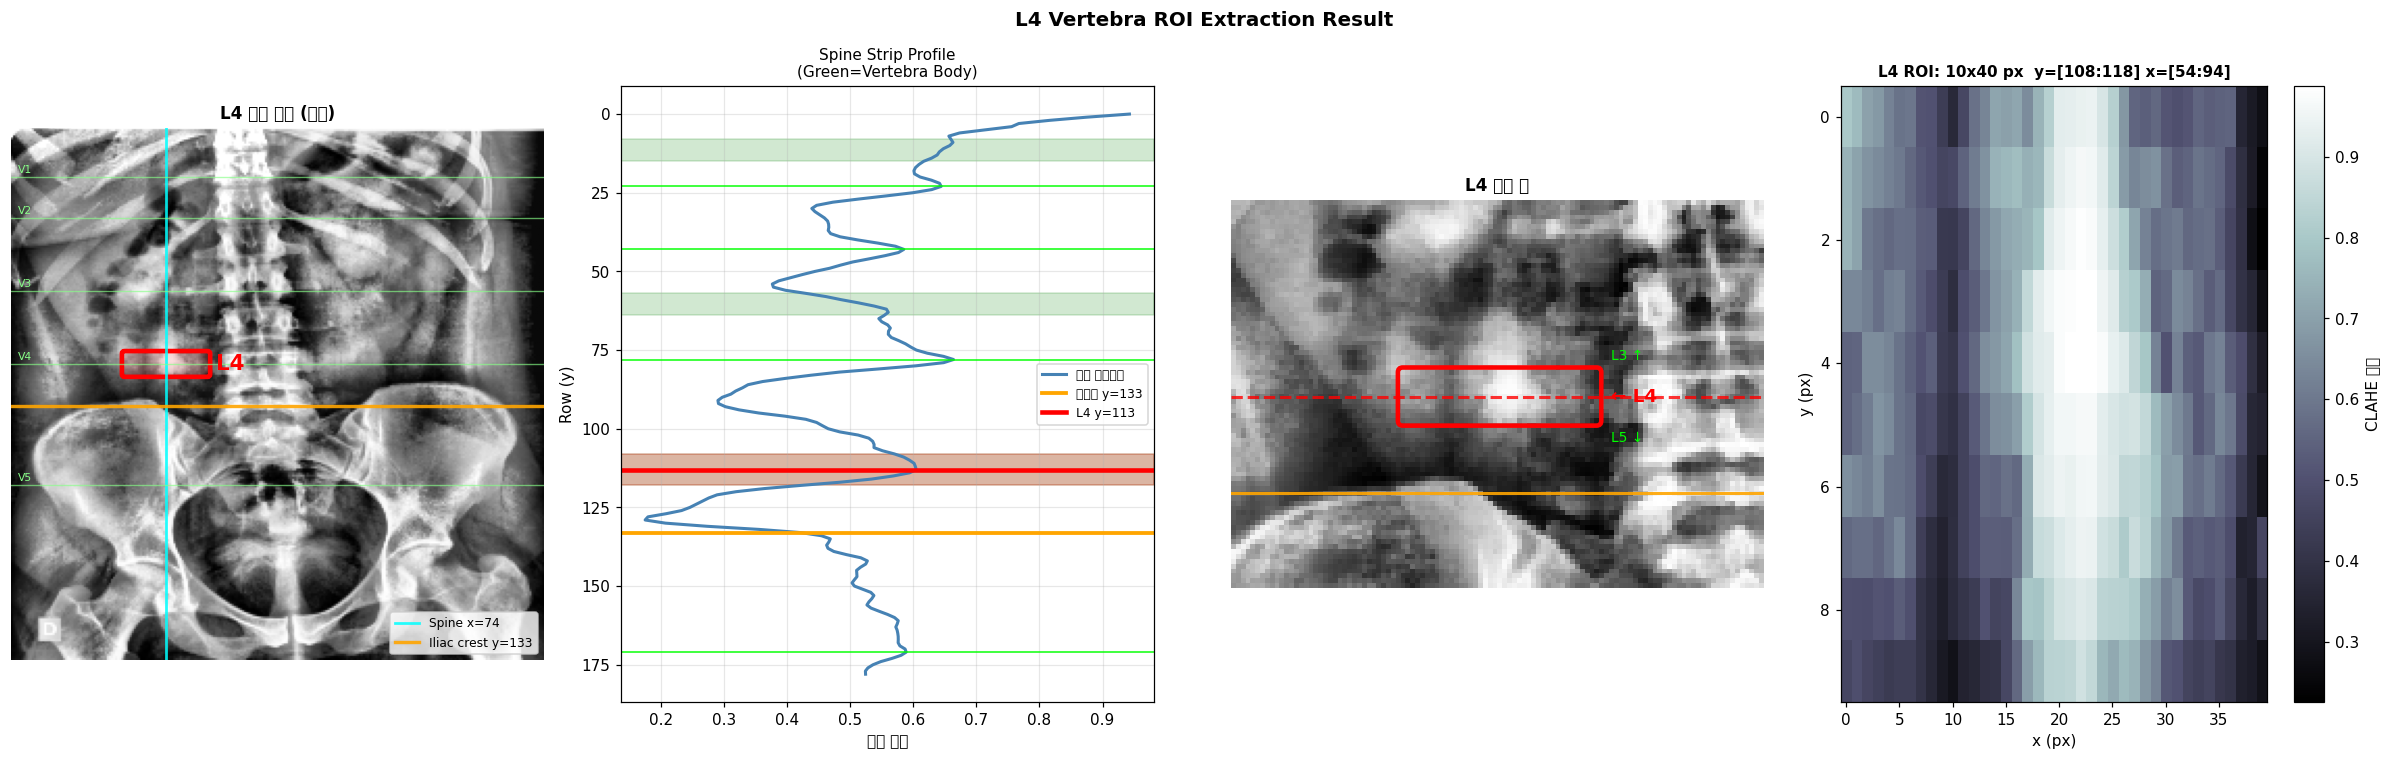

✅ L4 ROI 추출 완료: (10, 40)


In [7]:
def draw_l4_result(clahe, arr, spine_x, iliac_row, peaks,
                   t_l4, l4_ctr, b_l4, l4_x1, l4_x2,
                   vert_bounds, rp_s, save_path=None):
    """L4 탐지 결과 4-패널 대시보드"""
    h, w = clahe.shape
    fig, axes = plt.subplots(1, 4, figsize=(22, 7))
    
    # ── 패널 1: 전체 이미지 ──
    ax = axes[0]
    ax.imshow(clahe, cmap='gray')
    ax.axvline(spine_x,   color='cyan',   lw=1.8, alpha=0.85, label=f'Spine x={spine_x}')
    ax.axhline(iliac_row, color='#FFA500',lw=2.2, alpha=0.90, label=f'Iliac crest y={iliac_row}')
    # 모든 척추체 표시
    for i, p in enumerate(peaks):
        ax.axhline(p, color='#88FF88', lw=0.9, alpha=0.65)
        ax.text(3, p-1, f'V{i+1}', fontsize=7, color='#88FF88', va='bottom')
    # L4 ROI 박스
    rect = mpatches.FancyBboxPatch(
        (l4_x1, t_l4), l4_x2-l4_x1, b_l4-t_l4,
        boxstyle='round,pad=1.2', lw=3,
        edgecolor='red', facecolor='red', alpha=0.12)
    ax.add_patch(rect)
    rect2 = mpatches.FancyBboxPatch(
        (l4_x1, t_l4), l4_x2-l4_x1, b_l4-t_l4,
        boxstyle='round,pad=1.2', lw=3,
        edgecolor='red', facecolor='none')
    ax.add_patch(rect2)
    ax.text(l4_x2+4, l4_ctr, 'L4', color='red',
            fontsize=14, fontweight='bold', va='center')
    ax.legend(loc='lower right', fontsize=8)
    ax.set_title('L4 탐지 결과 (전체)', fontsize=11, fontweight='bold')
    ax.axis('off')
    
    # ── 패널 2: Row 프로파일 ──
    ax = axes[1]
    rows_ax = np.arange(len(rp_s))
    ax.plot(rp_s, rows_ax, 'steelblue', lw=2, label='강도 프로파일')
    for t, c, b in vert_bounds:
        ax.axhspan(t, b, alpha=0.18, color='green')
    for p in peaks:
        ax.axhline(p, color='lime', lw=1.2, alpha=0.8)
    ax.axhline(iliac_row, color='#FFA500', lw=2.5, label=f'장골능 y={iliac_row}')
    ax.axhline(l4_ctr, color='red', lw=3.0, label=f'L4 y={l4_ctr}')
    ax.axhspan(t_l4, b_l4, alpha=0.22, color='red')
    ax.invert_yaxis()
    ax.set_xlabel('평균 강도'); ax.set_ylabel('Row (y)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_title('Spine Strip Profile\n(Green=Vertebra Body)', fontsize=10)
    
    # ── 패널 3: L4 주변 확대 ──
    zy1 = max(0, t_l4-35); zy2 = min(h, b_l4+35)
    zx1 = max(0, spine_x-55); zx2 = min(w, spine_x+55)
    ax = axes[2]
    ax.imshow(clahe[zy1:zy2, zx1:zx2], cmap='gray')
    rect3 = mpatches.FancyBboxPatch(
        (l4_x1-zx1, t_l4-zy1), l4_x2-l4_x1, b_l4-t_l4,
        boxstyle='round,pad=1', lw=3,
        edgecolor='red', facecolor='none')
    ax.add_patch(rect3)
    ax.axhline(l4_ctr-zy1, color='red',     lw=2,   linestyle='--', alpha=0.8)
    ax.axhline(iliac_row-zy1, color='#FFA500', lw=2, alpha=0.9)
    ax.text(l4_x2-zx1+3, l4_ctr-zy1, '← L4',
            color='red', fontsize=12, fontweight='bold', va='center')
    ax.text(l4_x2-zx1+3, t_l4-zy1-2, 'L3 ↑',
            color='lime', fontsize=9, va='bottom')
    ax.text(l4_x2-zx1+3, b_l4-zy1+2, 'L5 ↓',
            color='lime', fontsize=9, va='top')
    ax.set_title('L4 확대 뷰', fontsize=11, fontweight='bold')
    ax.axis('off')
    
    # ── 패널 4: L4 ROI ──
    l4_roi = clahe[t_l4:b_l4, l4_x1:l4_x2]
    ax = axes[3]
    im = ax.imshow(l4_roi, cmap='bone', aspect='auto')
    plt.colorbar(im, ax=ax, label='CLAHE 강도')
    ps  = 0.1  # pixel spacing mm (placeholder)
    ax.set_title(
        f'L4 ROI: {l4_roi.shape[0]}x{l4_roi.shape[1]} px  y=[{t_l4}:{b_l4}] x=[{l4_x1}:{l4_x2}]',
        fontsize=10, fontweight='bold')
    ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
    
    plt.suptitle('L4 Vertebra ROI Extraction Result', fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()
    roi_clahe = clahe[t_l4:b_l4, l4_x1:l4_x2]
    roi_raw = arr[t_l4:b_l4, l4_x1:l4_x2] if arr is not None else roi_clahe
    return roi_clahe, roi_raw


l4_roi_clahe, l4_roi_raw = draw_l4_result(
    clahe, arr, spine_x, iliac_row, peaks,
    t_l4, l4_ctr, b_l4, l4_x1, l4_x2,
    vert_bounds, rp_s,
    save_path=f'{RESULT_DIR}/02_l4_detection.png'
)
print(f"✅ L4 ROI 추출 완료: {l4_roi_clahe.shape}")


## 🔧 Step 6: 단일 DICOM 완전 파이프라인 함수

In [8]:
def full_pipeline(dicom_path, visualize=False, save_dir=None):
    """
    DICOM → L4 ROI 완전 추출 파이프라인
    
    Returns:
        dict with keys:
            meta, norm, clahe, spine_x, iliac_row, peaks,
            t_l4, l4_ctr, b_l4, l4_x1, l4_x2,
            l4_roi_clahe, l4_roi_raw, status
    """
    result = {'status': 'OK', 'filename': os.path.basename(dicom_path)}
    try:
        arr, meta, dcm = load_dicom(dicom_path)
        norm, clahe, pad = preprocess_xray(arr, CFG['img_size'])
        h, w = clahe.shape
        
        spine_x, _   = detect_spine_x(clahe)
        peaks, troughs, vert_bounds, rp_s, d1 = detect_vertebrae_v5(clahe, spine_x)
        iliac_row, _ = detect_iliac_crest(clahe)
        (t_l4, l4_ctr, b_l4), (l4_x1, l4_x2) = localize_l4_v5(
            peaks, vert_bounds, iliac_row, h, spine_x, w)
        
        l4_roi_clahe = clahe[t_l4:b_l4, l4_x1:l4_x2]
        l4_roi_raw   = norm[t_l4:b_l4, l4_x1:l4_x2]
        
        result.update({
            'meta': meta, 'norm': norm, 'clahe': clahe,
            'spine_x': spine_x, 'iliac_row': iliac_row,
            'peaks': peaks, 'vert_bounds': vert_bounds, 'rp_s': rp_s,
            't_l4': t_l4, 'l4_ctr': l4_ctr, 'b_l4': b_l4,
            'l4_x1': l4_x1, 'l4_x2': l4_x2,
            'l4_roi_clahe': l4_roi_clahe,
            'l4_roi_raw':   l4_roi_raw,
        })
        
        if visualize:
            sp = f'{save_dir}/{meta["patient_id"]}_l4.png' if save_dir else None
            draw_l4_result(clahe, arr, spine_x, iliac_row, peaks,
                           t_l4, l4_ctr, b_l4, l4_x1, l4_x2,
                           vert_bounds, rp_s, save_path=sp)
    except Exception as e:
        result['status'] = f'ERROR: {e}'
    return result


# 테스트
res = full_pipeline(DICOM_FILE, visualize=False)
print(f"파이프라인 상태: {res['status']}")
if res['status'] == 'OK':
    print(f"  L4 ROI 크기: {res['l4_roi_clahe'].shape}")
    print(f"  L4 중심 Y  : {res['l4_ctr']}")


파이프라인 상태: OK
  L4 ROI 크기: (10, 40)
  L4 중심 Y  : 113


## 🧠 Step 7: U-Net 척추 세그멘테이션 모델

In [9]:
# ────────────────────────────────────────────────
# 척추 세그멘테이션 U-Net
# 출력: 7채널 마스크 (Background + L1 + L2 + L3 + L4 + L5 + Sacrum)
# ────────────────────────────────────────────────

class DoubleConvBlock(nn.Module):
    """Conv→BN→ReLU → Conv→BN→ReLU"""
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.conv = nn.Sequential(*layers)
    def forward(self, x): return self.conv(x)


class SpineUNet(nn.Module):
    """
    U-Net 척추 세그멘테이션
    
    입력:  (B, 1, H, W) - 단채널 X-ray
    출력:  (B, n_classes, H, W) - 클래스별 segmentation logits
    
    클래스:
        0: Background
        1: L1,  2: L2,  3: L3,  4: L4,  5: L5,  6: Sacrum
    """
    N_CLASSES = 7
    
    def __init__(self, in_ch=1, base_ch=32, dropout=0.1):
        super().__init__()
        # Encoder
        self.enc1 = DoubleConvBlock(in_ch,       base_ch,    dropout)
        self.enc2 = DoubleConvBlock(base_ch,      base_ch*2,  dropout)
        self.enc3 = DoubleConvBlock(base_ch*2,    base_ch*4,  dropout)
        self.enc4 = DoubleConvBlock(base_ch*4,    base_ch*8,  dropout)
        self.bottleneck = DoubleConvBlock(base_ch*8, base_ch*16, dropout)
        
        self.pool = nn.MaxPool2d(2)
        
        # Decoder
        self.up4   = nn.ConvTranspose2d(base_ch*16, base_ch*8,  2, stride=2)
        self.dec4  = DoubleConvBlock(base_ch*16, base_ch*8,  dropout)
        self.up3   = nn.ConvTranspose2d(base_ch*8,  base_ch*4,  2, stride=2)
        self.dec3  = DoubleConvBlock(base_ch*8,  base_ch*4,  dropout)
        self.up2   = nn.ConvTranspose2d(base_ch*4,  base_ch*2,  2, stride=2)
        self.dec2  = DoubleConvBlock(base_ch*4,  base_ch*2,  dropout)
        self.up1   = nn.ConvTranspose2d(base_ch*2,  base_ch,    2, stride=2)
        self.dec1  = DoubleConvBlock(base_ch*2,  base_ch,    dropout)
        
        self.out_conv = nn.Conv2d(base_ch, self.N_CLASSES, 1)
    
    def forward(self, x):
        # Encoder path
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        # Decoder path (skip connections)
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)


unet = SpineUNet(in_ch=1, base_ch=32, dropout=0.1).to(DEVICE)
n_params = sum(p.numel() for p in unet.parameters())
print(f"✅ SpineUNet 파라미터 수: {n_params:,}")

# 동작 확인
_x = torch.randn(2, 1, 256, 256).to(DEVICE)
_y = unet(_x)
print(f"   Forward test: {_x.shape} → {_y.shape}")
print(f"   출력 클래스: Background + L1~L5 + Sacrum = 7개")


✅ SpineUNet 파라미터 수: 7,762,663
   Forward test: torch.Size([2, 1, 256, 256]) → torch.Size([2, 7, 256, 256])
   출력 클래스: Background + L1~L5 + Sacrum = 7개


## 🔢 Step 8: BMD 회귀 모델 (ResNet-18 기반)

In [10]:
class BMDRegressor(nn.Module):
    """
    L4 ROI → BMD T-Score 회귀
    
    입력:  (B, 1, roi_size, roi_size) - L4 ROI 단채널
    출력:  (B, 1)                    - T-Score 예측값
    
    구조:
    - Backbone: ResNet-18 (첫 Conv를 단채널로 교체)
    - Head: FC(512→256→64→1) + Dropout
    
    학습 방식:
    A) DXA 레이블 있을 때: T-Score 직접 회귀 (MSELoss)
    B) 레이블 없을 때:     강도 기반 proxy score로 self-supervised pre-train
                           → 이후 소량 레이블로 fine-tune
    """
    def __init__(self, roi_size=64):
        super().__init__()
        backbone = models.resnet18(weights=None)
        # 단채널 입력으로 수정
        backbone.conv1 = nn.Conv2d(1, 64, 7, stride=2, padding=3, bias=False)
        in_features = backbone.fc.in_features
        backbone.fc  = nn.Identity()
        self.backbone = backbone
        
        self.head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(), nn.Dropout(0.35),
            nn.Linear(256, 64),
            nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
        self._init_weights()
    
    def _init_weights(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        feat = self.backbone(x)
        return self.head(feat)


bmd_model = BMDRegressor(roi_size=CFG['roi_size']).to(DEVICE)
n_params  = sum(p.numel() for p in bmd_model.parameters())
print(f"✅ BMDRegressor 파라미터 수: {n_params:,}")
_x2 = torch.randn(4, 1, 64, 64).to(DEVICE)
_y2 = bmd_model(_x2)
print(f"   Forward test: {_x2.shape} → {_y2.shape}")


✅ BMDRegressor 파라미터 수: 11,318,081
   Forward test: torch.Size([4, 1, 64, 64]) → torch.Size([4, 1])


## 📊 Step 9: Dataset & DataLoader (교체 가능한 구조)

In [11]:
class SpineDICOMDataset(Dataset):
    """
    DICOM 폴더 기반 Dataset
    
    ─ 레이블 없을 때 ─
    label_df=None이면 pixel intensity proxy T-score를 자동 계산
    
    ─ 레이블 있을 때 ─
    label_df 컬럼: ['filename', 't_score']
    
    ─ 데이터 증강 ─
    augment=True: 좌우 반전, 회전(±5°), 밝기/대비 조정
    """
    LABEL_CLASSES = {0:'BG', 1:'L1', 2:'L2', 3:'L3', 4:'L4', 5:'L5', 6:'Sacrum'}
    
    def __init__(self, dicom_paths, label_df=None, augment=False,
                 img_size=256, roi_size=64):
        self.paths     = dicom_paths
        self.label_df  = label_df
        self.augment   = augment
        self.img_size  = img_size
        self.roi_size  = roi_size
        
        # 레이블 dict 구성
        self.labels = {}
        if label_df is not None:
            for _, row in label_df.iterrows():
                self.labels[row['filename']] = float(row['t_score'])
    
    def __len__(self): return len(self.paths)
    
    def _proxy_tscore(self, roi_raw, meta):
        """레이블 없을 때: pixel 강도 기반 proxy T-score"""
        if roi_raw.size == 0: return 0.0
        flat     = roi_raw.ravel()
        lo, hi   = np.percentile(flat, [10, 90])
        core     = flat[(flat >= lo) & (flat <= hi)]
        trimmed  = float(np.mean(core)) if len(core) > 0 else float(flat.mean())
        t_score  = (trimmed - CFG['ref_young_mean']) / CFG['ref_young_std']
        return float(np.clip(t_score, -5.0, 2.0))
    
    def _augment(self, roi):
        """데이터 증강 (numpy 배열 입력)"""
        # 좌우 반전 (척추 X-ray는 좌우 반전 무방)
        if np.random.rand() < 0.5:
            roi = np.fliplr(roi).copy()
        # 소폭 회전 (±5°)
        angle = np.random.uniform(-5, 5)
        h, w  = roi.shape
        M     = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        roi   = cv2.warpAffine(roi, M, (w, h),
                               borderMode=cv2.BORDER_REFLECT)
        # 밝기 스케일 (±10%)
        scale = np.random.uniform(0.90, 1.10)
        roi   = np.clip(roi * scale, 0, 1)
        return roi.astype(np.float32)
    
    def __getitem__(self, idx):
        path = self.paths[idx]
        fname = os.path.basename(path)
        
        try:
            res = full_pipeline(path)
            if res['status'] != 'OK':
                raise ValueError(res['status'])
            
            roi = res['l4_roi_raw'].astype(np.float32)
            
            # ROI 크기 정규화
            if roi.size == 0 or roi.shape[0] < 4 or roi.shape[1] < 4:
                roi = np.zeros((self.roi_size, self.roi_size), dtype=np.float32)
            else:
                roi = cv2.resize(roi, (self.roi_size, self.roi_size))
            
            # 증강
            if self.augment:
                roi = self._augment(roi)
            
            # 레이블
            if fname in self.labels:
                t_score = self.labels[fname]
            else:
                t_score = self._proxy_tscore(roi, res['meta'])
            
            # 전체 이미지도 반환 (U-Net 학습용)
            full_img = res['clahe'].astype(np.float32)
            
        except Exception as e:
            roi      = np.zeros((self.roi_size, self.roi_size), dtype=np.float32)
            full_img = np.zeros((self.img_size, self.img_size), dtype=np.float32)
            t_score  = 0.0
        
        roi_tensor  = torch.FloatTensor(roi).unsqueeze(0)       # (1, R, R)
        img_tensor  = torch.FloatTensor(full_img).unsqueeze(0)  # (1, H, W)
        label_tensor = torch.FloatTensor([t_score])             # (1,)
        
        return {
            'roi':      roi_tensor,
            'image':    img_tensor,
            'label':    label_tensor,
            'filename': fname,
        }


def build_dataloaders(dataset_root, label_csv=None, cfg=CFG):
    """
    데이터셋 루트에서 train/val/test DataLoader 생성.
    
    폴더 구조 1 (train/val/test 분리):
        dataset_root/train/*.dcm
        dataset_root/val/*.dcm
        dataset_root/test/*.dcm
    
    폴더 구조 2 (단일 폴더, 자동 분할):
        dataset_root/*.dcm   → 7:1.5:1.5 분할
    """
    label_df = None
    if label_csv and os.path.exists(label_csv):
        label_df = pd.read_csv(label_csv)
        print(f"레이블 파일 로딩: {len(label_df)}개 레이블")
    
    def glob_dcm(folder):
        p = (glob.glob(os.path.join(folder, '*.dcm')) +
             glob.glob(os.path.join(folder, '*.DCM')) +
             glob.glob(os.path.join(folder, '**', '*.dcm'), recursive=True))
        return sorted(set(p))
    
    # 폴더 구조 1 확인
    train_f = glob_dcm(os.path.join(dataset_root, 'train'))
    val_f   = glob_dcm(os.path.join(dataset_root, 'val'))
    test_f  = glob_dcm(os.path.join(dataset_root, 'test'))
    
    if train_f:
        print(f"폴더 구조 1 감지: train={len(train_f)}, val={len(val_f)}, test={len(test_f)}")
    else:
        # 폴더 구조 2: 자동 분할
        all_files = glob_dcm(dataset_root)
        if not all_files:
            print(f"⚠️  DICOM 파일 없음: {dataset_root}")
            return None, None, None
        np.random.seed(42)
        idx = np.random.permutation(len(all_files))
        n_tr  = int(len(idx) * cfg['train_ratio'])
        n_val = int(len(idx) * cfg['val_ratio'])
        train_f = [all_files[i] for i in idx[:n_tr]]
        val_f   = [all_files[i] for i in idx[n_tr:n_tr+n_val]]
        test_f  = [all_files[i] for i in idx[n_tr+n_val:]]
        print(f"자동 분할: train={len(train_f)}, val={len(val_f)}, test={len(test_f)}")
    
    ds_train = SpineDICOMDataset(train_f, label_df, augment=True,
                                  img_size=cfg['img_size'], roi_size=cfg['roi_size'])
    ds_val   = SpineDICOMDataset(val_f,   label_df, augment=False,
                                  img_size=cfg['img_size'], roi_size=cfg['roi_size'])
    ds_test  = SpineDICOMDataset(test_f,  label_df, augment=False,
                                  img_size=cfg['img_size'], roi_size=cfg['roi_size'])
    
    dl_train = DataLoader(ds_train, batch_size=cfg['batch_size'],
                          shuffle=True,  num_workers=0, pin_memory=False)
    dl_val   = DataLoader(ds_val,   batch_size=cfg['batch_size'],
                          shuffle=False, num_workers=0, pin_memory=False)
    dl_test  = DataLoader(ds_test,  batch_size=1,
                          shuffle=False, num_workers=0, pin_memory=False)
    
    return dl_train, dl_val, dl_test


print("✅ Dataset 클래스 정의 완료")
print("   사용법: dl_train, dl_val, dl_test = build_dataloaders(DATASET_ROOT)")


✅ Dataset 클래스 정의 완료
   사용법: dl_train, dl_val, dl_test = build_dataloaders(DATASET_ROOT)


## 🏋️ Step 10: 모델 훈련 (Train / Validation / Test)

In [12]:
def train_bmd_model(model, dl_train, dl_val, cfg=CFG,
                    save_path=None):
    """
    BMDRegressor 훈련 루프
    
    - Optimizer: AdamW + CosineAnnealingLR
    - Loss: HuberLoss (MSE보다 outlier 강건)
    - Early Stopping: val loss 기준
    - 최적 모델 자동 저장
    """
    optimizer = optim.AdamW(model.parameters(),
                            lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg['num_epochs'], eta_min=1e-6)
    criterion = nn.HuberLoss(delta=0.5)
    
    history = {'train_loss': [], 'val_loss': [], 'val_mae': []}
    best_val_loss = float('inf')
    patience_cnt  = 0
    
    for epoch in range(1, cfg['num_epochs'] + 1):
        # ── 훈련 ──
        model.train()
        tr_loss = 0.0
        for batch in tqdm(dl_train, desc=f'Epoch {epoch:3d} Train',
                          leave=False, ncols=80):
            rois   = batch['roi'].to(DEVICE)
            labels = batch['label'].to(DEVICE)
            optimizer.zero_grad()
            preds = model(rois)
            loss  = criterion(preds, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tr_loss += loss.item()
        
        tr_loss /= max(len(dl_train), 1)
        scheduler.step()
        
        # ── 검증 ──
        model.eval()
        val_loss = 0.0
        val_mae  = 0.0
        with torch.no_grad():
            for batch in dl_val:
                rois   = batch['roi'].to(DEVICE)
                labels = batch['label'].to(DEVICE)
                preds  = model(rois)
                val_loss += criterion(preds, labels).item()
                val_mae  += torch.abs(preds - labels).mean().item()
        
        val_loss /= max(len(dl_val), 1)
        val_mae  /= max(len(dl_val), 1)
        
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['val_mae'].append(val_mae)
        
        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_cnt  = 0
            if save_path:
                torch.save(model.state_dict(), save_path)
                print(f"  Epoch {epoch:3d} | train={tr_loss:.4f} "
                      f"val={val_loss:.4f} MAE={val_mae:.3f} 💾 저장")
        else:
            patience_cnt += 1
            if epoch % 5 == 0:
                print(f"  Epoch {epoch:3d} | train={tr_loss:.4f} "
                      f"val={val_loss:.4f} MAE={val_mae:.3f} "
                      f"(patience {patience_cnt}/{cfg['early_stop']})")
            if patience_cnt >= cfg['early_stop']:
                print(f"  Early stopping at epoch {epoch}")
                break
    
    return history


def evaluate_model(model, dl_test, model_path=None):
    """테스트셋 평가 + 결과 리포트"""
    if model_path and os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        print(f"최적 모델 로딩: {model_path}")
    
    model.eval()
    all_preds, all_labels, all_fnames = [], [], []
    
    with torch.no_grad():
        for batch in dl_test:
            preds  = model(batch['roi'].to(DEVICE)).cpu().numpy()
            labels = batch['label'].numpy()
            all_preds.extend(preds.flatten())
            all_labels.extend(labels.flatten())
            all_fnames.extend(batch['filename'])
    
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    mae  = np.mean(np.abs(all_preds - all_labels))
    rmse = np.sqrt(np.mean((all_preds - all_labels)**2))
    
    print(f"\n{'═'*45}")
    print(f"  테스트 결과 (n={len(all_preds)})")
    print(f"{'─'*45}")
    print(f"  MAE  (T-score): {mae:.3f}")
    print(f"  RMSE (T-score): {rmse:.3f}")
    print(f"{'═'*45}")
    
    return {
        'preds': all_preds, 'labels': all_labels,
        'fnames': all_fnames, 'mae': mae, 'rmse': rmse
    }


def plot_training_history(history, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ep = range(1, len(history['train_loss'])+1)
    axes[0].plot(ep, history['train_loss'], label='Train Loss', color='steelblue')
    axes[0].plot(ep, history['val_loss'],   label='Val Loss',   color='tomato')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Huber Loss')
    axes[0].set_title('Training & Validation Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(ep, history['val_mae'], color='green')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE (T-score)')
    axes[1].set_title('Validation MAE'); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=120)
    plt.show()


print("✅ 훈련 함수 정의 완료")
print()
print("─── 훈련 실행 방법 ───────────────────────────────")
print("dl_train, dl_val, dl_test = build_dataloaders(DATASET_ROOT)")
print("history = train_bmd_model(")
print("    bmd_model, dl_train, dl_val, cfg=CFG,")
print(f"    save_path='{MODEL_DIR}/best_bmd.pth')")
print("plot_training_history(history)")
print("eval_result = evaluate_model(bmd_model, dl_test,")
print(f"    model_path='{MODEL_DIR}/best_bmd.pth')")
print("──────────────────────────────────────────────────")


✅ 훈련 함수 정의 완료

─── 훈련 실행 방법 ───────────────────────────────
dl_train, dl_val, dl_test = build_dataloaders(DATASET_ROOT)
history = train_bmd_model(
    bmd_model, dl_train, dl_val, cfg=CFG,
    save_path='./bmd_output\models/best_bmd.pth')
plot_training_history(history)
eval_result = evaluate_model(bmd_model, dl_test,
    model_path='./bmd_output\models/best_bmd.pth')
──────────────────────────────────────────────────


## ▶️ Step 11: 훈련 실행 (데이터셋 준비 후 실행)

In [13]:
# ══════════════════════════════════════════════════
#   ⚠️  데이터셋이 준비된 경우에만 아래 셀 실행하세요
#   DATASET_ROOT에 train/val/test 폴더 또는 *.dcm 파일 배치 필요
# ══════════════════════════════════════════════════

RUN_TRAINING = os.path.exists(DATASET_ROOT) and (
    len(glob.glob(os.path.join(DATASET_ROOT, '**', '*.dcm'), recursive=True)) > 0
)
print(f"데이터셋 감지: {RUN_TRAINING}")
print(f"데이터셋 경로: {DATASET_ROOT}")

if RUN_TRAINING:
    print("\n🚀 훈련 시작...")
    dl_train, dl_val, dl_test = build_dataloaders(
        DATASET_ROOT, label_csv=LABEL_CSV if os.path.exists(LABEL_CSV) else None
    )
    
    if dl_train:
        SAVE_PATH = f'{MODEL_DIR}/best_bmd.pth'
        history = train_bmd_model(
            bmd_model, dl_train, dl_val, cfg=CFG, save_path=SAVE_PATH
        )
        plot_training_history(
            history, save_path=f'{RESULT_DIR}/training_history.png'
        )
        eval_result = evaluate_model(bmd_model, dl_test, model_path=SAVE_PATH)
else:
    print("\n데이터셋 미준비 → 단일 파일 추론 모드로 실행합니다.")
    print("데이터셋 준비 후 DATASET_ROOT 경로를 지정하고 이 셀을 재실행하세요.")


데이터셋 감지: False
데이터셋 경로: ./dataset

데이터셋 미준비 → 단일 파일 추론 모드로 실행합니다.
데이터셋 준비 후 DATASET_ROOT 경로를 지정하고 이 셀을 재실행하세요.


## 📋 Step 12: BMD 측정 & WHO 분류 (단일 파일)

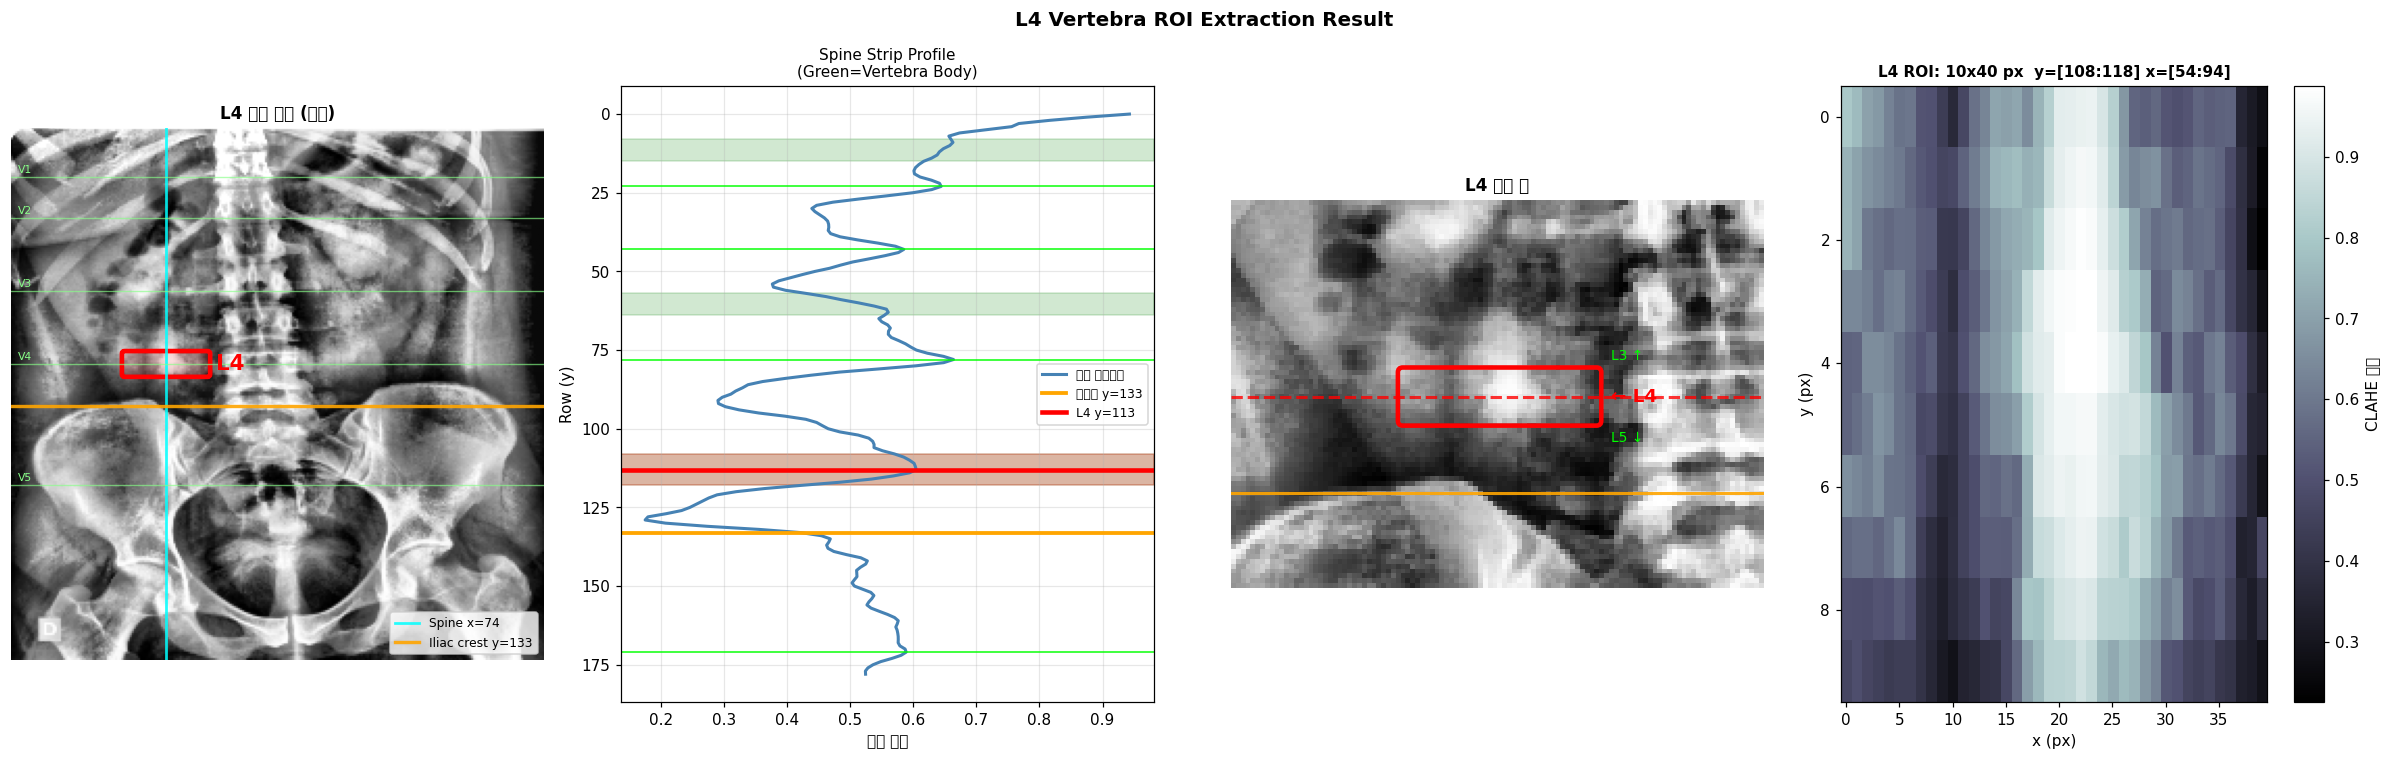


════════════════════════════════════════════════════
  L4 골밀도 분석 리포트
════════════════════════════════════════════════════
  환자 ID         : 1035
  검사일          : 
  성별/나이       :  / 
  모달리티        : CR
────────────────────────────────────────────────────
  L4 ROI 크기     : (10, 40)
  평균 픽셀 강도  : 0.6
  Trimmed Mean    : 0.6
────────────────────────────────────────────────────
  BMD Proxy Score : 0.0/100
  T-Score (proxy) : -13.00
  T-Score (DL)    : -0.41
  T-Score (최종)  : -0.41
  Z-Score         : -9.25
────────────────────────────────────────────────────
  WHO 분류        : Normal
  골절 위험도     : Low
  측정 방식       : DL+Proxy
════════════════════════════════════════════════════
  ⚠️  스크리닝 지표 (DEXA 대체 불가) - 전문의 판독 필요


In [14]:
def estimate_bmd_from_roi(roi_raw, model=None, meta=None, cfg=CFG):
    """
    L4 ROI → BMD T-Score 추정
    
    두 가지 방식:
    A) 딥러닝 모델 있을 때: ResNet-18 회귀 예측값 사용
    B) 모델 없을 때:        pixel intensity proxy 사용
    """
    if roi_raw.size == 0:
        return None
    
    # ─ 방식 A: 딥러닝 모델 ─
    if model is not None:
        model.eval()
        roi_r = cv2.resize(roi_raw.astype(np.float32),
                           (cfg['roi_size'], cfg['roi_size']))
        tensor = torch.FloatTensor(roi_r).unsqueeze(0).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            t_score_dl = float(model(tensor).cpu().item())
    else:
        t_score_dl = None
    
    # ─ 방식 B: Pixel 강도 기반 ─
    flat    = roi_raw.ravel()
    lo, hi  = np.percentile(flat, [10, 90])
    core    = flat[(flat >= lo) & (flat <= hi)]
    trimmed = float(np.mean(core)) if len(core) > 0 else float(flat.mean())
    t_score_proxy = (trimmed - cfg['ref_young_mean']) / cfg['ref_young_std']
    z_score       = (trimmed - cfg['ref_age_mean'])   / cfg['ref_age_std']
    bmd_proxy     = float(np.clip((trimmed / cfg['ref_young_mean']) * 100, 0, 130))
    
    # 최종 T-score: 딥러닝 우선, 없으면 proxy
    t_final = t_score_dl if t_score_dl is not None else t_score_proxy
    
    # WHO 분류
    if t_final >= -1.0:
        who, risk, color = "Normal",                  "Low",      "#27ae60"
    elif t_final >= -2.5:
        who, risk, color = "Osteopenia (저골밀도)",    "Moderate", "#e67e22"
    else:
        who, risk, color = "Osteoporosis (골다공증)",  "High",     "#e74c3c"
    
    return {
        'mean_pixel':    float(flat.mean()),
        'trimmed_mean':  trimmed,
        'bmd_proxy':     bmd_proxy,
        't_score_proxy': t_score_proxy,
        't_score_dl':    t_score_dl,
        't_score_final': t_final,
        'z_score':       z_score,
        'who':           who,
        'fracture_risk': risk,
        'risk_color':    color,
        'method':        'DL+Proxy' if t_score_dl else 'Proxy only',
    }


def print_bmd_report(bmd, meta, l4_shape):
    print("\n" + "═"*52)
    print("  L4 골밀도 분석 리포트")
    print("═"*52)
    print(f"  환자 ID         : {meta.get('patient_id','Unknown')}")
    print(f"  검사일          : {meta.get('study_date','Unknown')}")
    print(f"  성별/나이       : {meta.get('patient_sex','?')} / {meta.get('patient_age','?')}")
    print(f"  모달리티        : {meta.get('modality','CR')}")
    print("─"*52)
    print(f"  L4 ROI 크기     : {l4_shape}")
    print(f"  평균 픽셀 강도  : {bmd['mean_pixel']:.1f}")
    print(f"  Trimmed Mean    : {bmd['trimmed_mean']:.1f}")
    print("─"*52)
    print(f"  BMD Proxy Score : {bmd['bmd_proxy']:.1f}/100")
    print(f"  T-Score (proxy) : {bmd['t_score_proxy']:+.2f}")
    if bmd['t_score_dl'] is not None:
        print(f"  T-Score (DL)    : {bmd['t_score_dl']:+.2f}")
    print(f"  T-Score (최종)  : {bmd['t_score_final']:+.2f}")
    print(f"  Z-Score         : {bmd['z_score']:+.2f}")
    print("─"*52)
    print(f"  WHO 분류        : {bmd['who']}")
    print(f"  골절 위험도     : {bmd['fracture_risk']}")
    print(f"  측정 방식       : {bmd['method']}")
    print("═"*52)
    print("  ⚠️  스크리닝 지표 (DEXA 대체 불가) - 전문의 판독 필요")


# ── 샘플 파일 BMD 측정 ──
res = full_pipeline(DICOM_FILE, visualize=True,
                    save_dir=RESULT_DIR)

if res['status'] == 'OK':
    bmd = estimate_bmd_from_roi(
        res['l4_roi_raw'],
        model=bmd_model,
        meta=res['meta']
    )
    print_bmd_report(bmd, res['meta'], res['l4_roi_raw'].shape)
else:
    print(f"파이프라인 오류: {res['status']}")


## 📊 Step 13: BMD 결과 대시보드

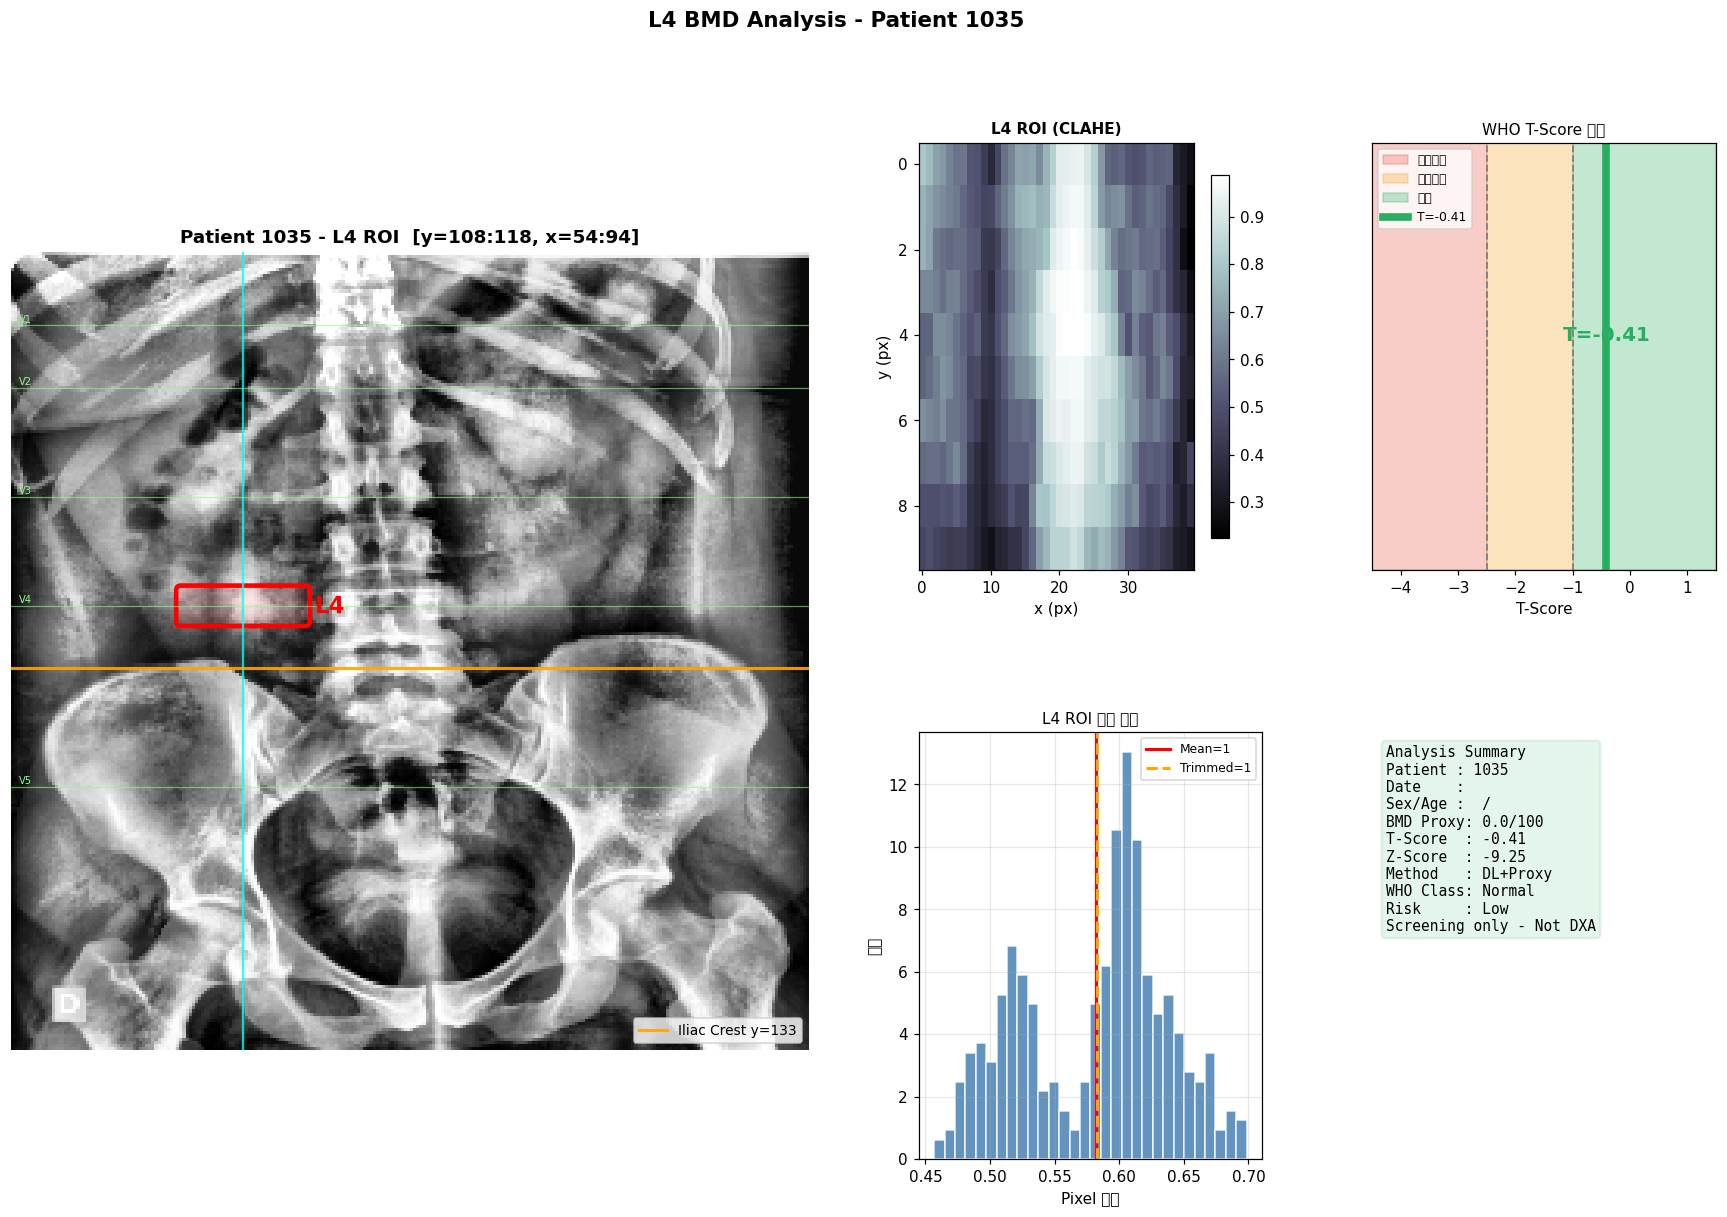

In [15]:
def plot_bmd_dashboard(res, bmd, save_path=None):
    """6-패널 BMD 결과 대시보드"""
    if res['status'] != 'OK' or bmd is None:
        print("결과 없음")
        return
    
    clahe     = res['clahe']
    l4_roi    = res['l4_roi_clahe']
    l4_roi_r  = res['l4_roi_raw']
    t_l4      = res['t_l4']; b_l4 = res['b_l4']
    l4_x1     = res['l4_x1']; l4_x2 = res['l4_x2']
    l4_ctr    = res['l4_ctr']
    spine_x   = res['spine_x']
    iliac_row = res['iliac_row']
    peaks     = res['peaks']
    meta      = res['meta']
    h, w      = clahe.shape
    
    fig = plt.figure(figsize=(20, 12))
    gs  = GridSpec(2, 4, figure=fig, hspace=0.38, wspace=0.32)
    
    # ── [0,0:2] 전체 X-ray ──
    ax = fig.add_subplot(gs[:, 0:2])
    ax.imshow(clahe, cmap='gray')
    ax.axvline(spine_x,   color='cyan',     lw=1.5, alpha=0.8)
    ax.axhline(iliac_row, color='#FFA500',  lw=2,   alpha=0.9,
               label=f'Iliac Crest y={iliac_row}')
    for i, p in enumerate(peaks):
        ax.axhline(p, color='#88FF88', lw=0.8, alpha=0.6)
        ax.text(2, p-1, f'V{i+1}', fontsize=6.5, color='#88FF88')
    rect = mpatches.FancyBboxPatch(
        (l4_x1, t_l4), l4_x2-l4_x1, b_l4-t_l4,
        boxstyle='round,pad=1.5', lw=3,
        edgecolor='red', facecolor='red', alpha=0.1)
    ax.add_patch(rect)
    rect2 = mpatches.FancyBboxPatch(
        (l4_x1, t_l4), l4_x2-l4_x1, b_l4-t_l4,
        boxstyle='round,pad=1.5', lw=3,
        edgecolor='red', facecolor='none')
    ax.add_patch(rect2)
    ax.text(l4_x2+3, l4_ctr, 'L4', color='red',
            fontsize=15, fontweight='bold', va='center')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_title(
        f"Patient {meta['patient_id']} - L4 ROI  [y={t_l4}:{b_l4}, x={l4_x1}:{l4_x2}]",
        fontsize=12, fontweight='bold')
    ax.axis('off')
    
    # ── [0,2] L4 ROI ──
    ax = fig.add_subplot(gs[0, 2])
    im = ax.imshow(l4_roi, cmap='bone', aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.85)
    ax.set_title('L4 ROI (CLAHE)', fontsize=10, fontweight='bold')
    ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
    
    # ── [1,2] 픽셀 분포 ──
    ax = fig.add_subplot(gs[1, 2])
    flat = l4_roi_r.ravel()
    ax.hist(flat, bins=30, color='steelblue', edgecolor='white',
            alpha=0.85, density=True)
    ax.axvline(bmd['mean_pixel'],   color='red',    lw=2,
               label=f"Mean={bmd['mean_pixel']:.0f}")
    ax.axvline(bmd['trimmed_mean'], color='orange', lw=2, linestyle='--',
               label=f"Trimmed={bmd['trimmed_mean']:.0f}")
    ax.legend(fontsize=8); ax.set_xlabel('Pixel 강도')
    ax.set_ylabel('밀도')
    ax.set_title('L4 ROI 픽셀 분포', fontsize=10)
    ax.grid(alpha=0.3)
    
    # ── [0,3] T-Score 게이지 ──
    ax = fig.add_subplot(gs[0, 3])
    t = bmd['t_score_final']
    ax.set_xlim(-4.5, 1.5); ax.set_ylim(0, 1)
    ax.axvspan(-4.5, -2.5, color='#e74c3c', alpha=0.28, label='골다공증')
    ax.axvspan(-2.5, -1.0, color='#f39c12', alpha=0.28, label='골감소증')
    ax.axvspan(-1.0,  1.5, color='#27ae60', alpha=0.28, label='정상')
    ax.axvline(t, color=bmd['risk_color'], lw=5,
               label=f'T={t:+.2f}')
    ax.axvline(-2.5, color='gray', lw=1.2, linestyle='--')
    ax.axvline(-1.0, color='gray', lw=1.2, linestyle='--')
    ax.text(t, 0.55, f'T={t:+.2f}',
            color=bmd['risk_color'], fontsize=13,
            fontweight='bold', ha='center', va='center')
    ax.set_xlabel('T-Score', fontsize=10); ax.set_yticks([])
    ax.legend(fontsize=8, loc='upper left')
    ax.set_title('WHO T-Score 분류', fontsize=10)
    
    # ── [1,3] 요약 텍스트 ──
    ax = fig.add_subplot(gs[1, 3])
    ax.axis('off')
    summary = (
        "Analysis Summary\n"
        f"Patient : {meta['patient_id']}\n"
        f"Date    : {meta['study_date']}\n"
        f"Sex/Age : {meta.get('patient_sex','?')} / {meta.get('patient_age','?')}\n"
        f"BMD Proxy: {bmd['bmd_proxy']:.1f}/100\n"
        f"T-Score  : {bmd['t_score_final']:+.2f}\n"
        f"Z-Score  : {bmd['z_score']:+.2f}\n"
        f"Method   : {bmd['method']}\n"
        f"WHO Class: {bmd['who']}\n"
        f"Risk     : {bmd['fracture_risk']}\n"
        "Screening only - Not DXA"
    )
    ax.text(0.04, 0.97, summary,
            transform=ax.transAxes,
            fontsize=9.5, va='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor=bmd['risk_color'],
                      alpha=0.12, edgecolor=bmd['risk_color'], lw=1.5))
    
    plt.suptitle(
        f"L4 BMD Analysis - Patient {meta['patient_id']}",
        fontsize=14, fontweight='bold')
    
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()


plot_bmd_dashboard(res, bmd,
    save_path=f"{RESULT_DIR}/03_bmd_dashboard.png")


## 🗂️ Step 14: 배치 처리 & CSV 리포트

DICOM 파일 없음 - 샘플 1개로 시뮬레이션


Batch BMD:   0%|                                          | 0/1 [00:00<?, ?it/s]

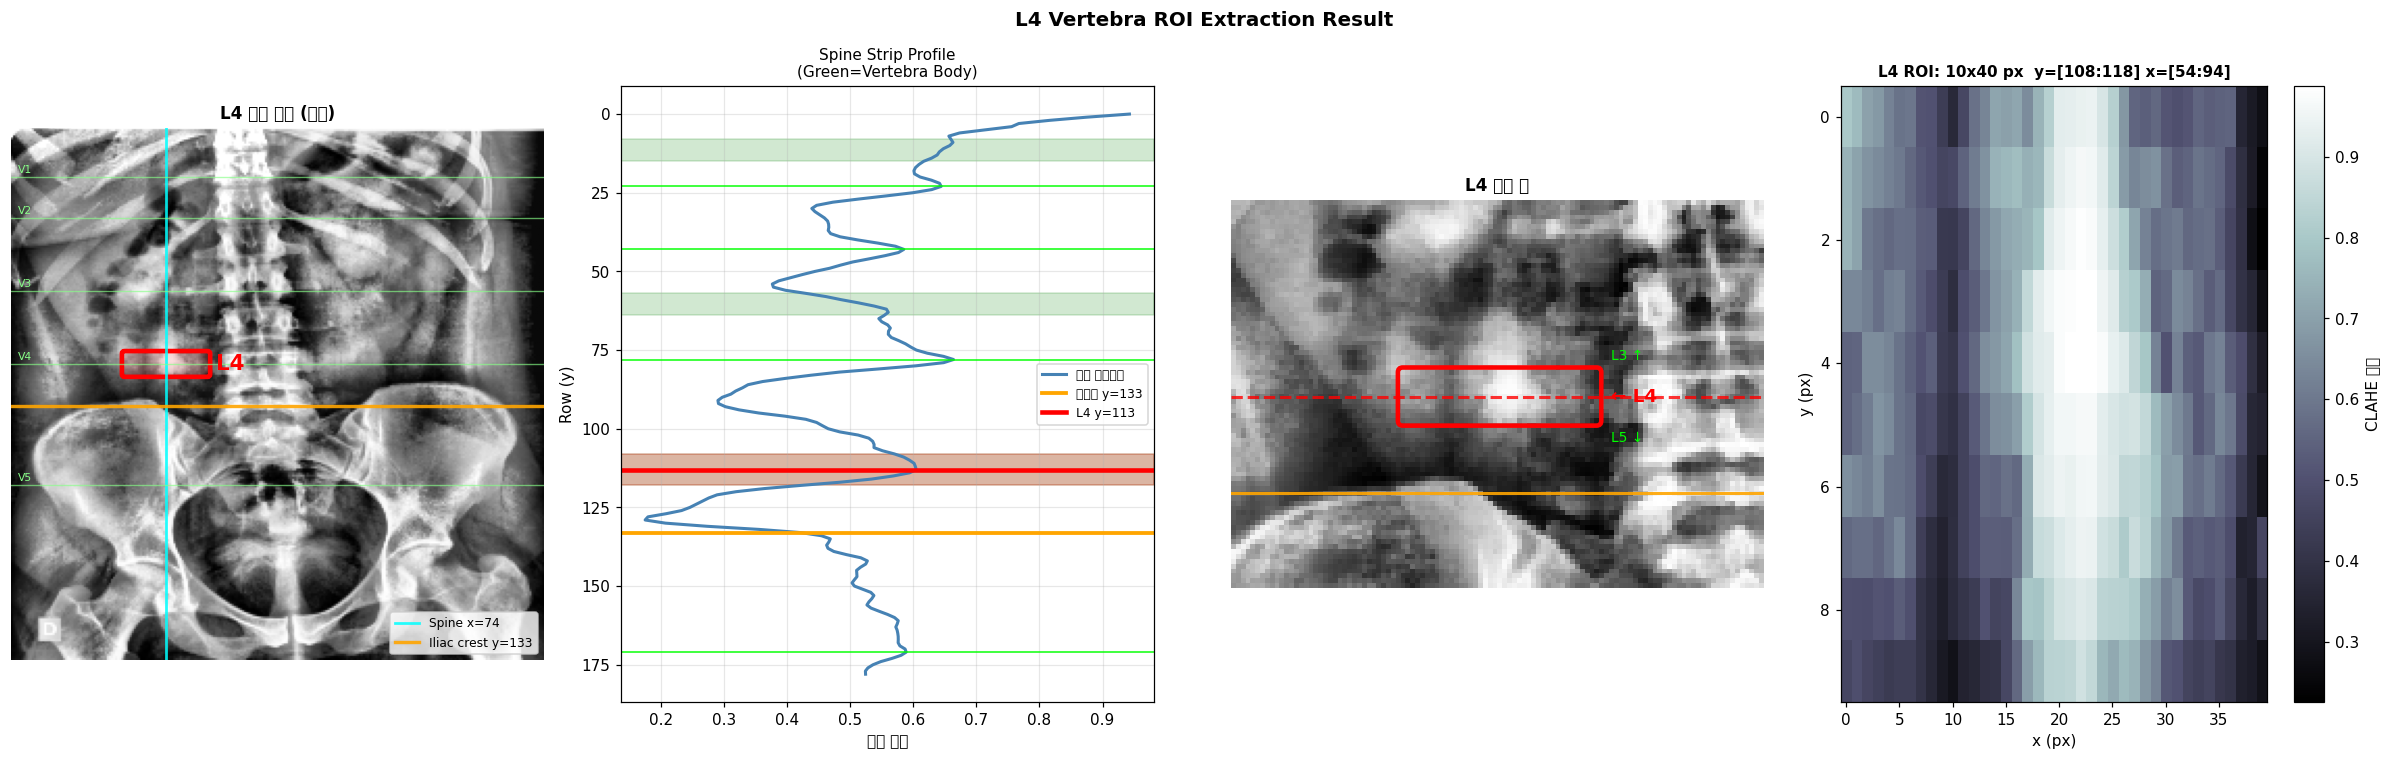

Batch BMD: 100%|██████████████████████████████████| 1/1 [00:00<00:00,  1.01it/s]


✅ 배치 완료: 1개 처리
   CSV 저장: ./bmd_output\results/batch\bmd_batch_report.csv

   T-Score 통계 (n=1)
   평균: -0.41 | 최소: -0.41 | 최대: -0.41
   Normal                        : 1명 (100.0%)
   idx                                                                filename status patient_id study_date patient_sex patient_age            l4_bbox  l4_height_px  l4_width_px mean_pixel bmd_proxy t_score z_score who_class fracture_risk    method
0    1  1.2.826.0.1.3680043.8.498.11227155170490832168629184106125649390-c.dcm     OK       1035                                     y=108:118,x=54:94            10           40        0.6       0.0  -0.415  -9.250    Normal           Low  DL+Proxy


In [16]:
def run_batch(dicom_paths, model=None, save_dir=None):
    """
    여러 DICOM 파일 일괄 처리
    → CSV 리포트 + 결과 이미지 저장
    """
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
    
    rows = []
    for i, path in enumerate(tqdm(dicom_paths, desc='Batch BMD', ncols=80)):
        r = full_pipeline(path)
        row = {'idx': i+1, 'filename': os.path.basename(path),
               'status': r['status']}
        
        if r['status'] == 'OK':
            bmd = estimate_bmd_from_roi(r['l4_roi_raw'], model=model,
                                         meta=r['meta'])
            if bmd:
                meta = r['meta']
                row.update({
                    'patient_id':    meta['patient_id'],
                    'study_date':    meta['study_date'],
                    'patient_sex':   meta['patient_sex'],
                    'patient_age':   meta['patient_age'],
                    'l4_bbox':       f"y={r['t_l4']}:{r['b_l4']},x={r['l4_x1']}:{r['l4_x2']}",
                    'l4_height_px':  r['b_l4'] - r['t_l4'],
                    'l4_width_px':   r['l4_x2'] - r['l4_x1'],
                    'mean_pixel':    f"{bmd['mean_pixel']:.1f}",
                    'bmd_proxy':     f"{bmd['bmd_proxy']:.1f}",
                    't_score':       f"{bmd['t_score_final']:+.3f}",
                    'z_score':       f"{bmd['z_score']:+.3f}",
                    'who_class':     bmd['who'],
                    'fracture_risk': bmd['fracture_risk'],
                    'method':        bmd['method'],
                })
                # 결과 이미지 저장
                if save_dir:
                    pid = meta['patient_id'].replace('/', '_')
                    draw_l4_result(
                        r['clahe'], None, r['spine_x'], r['iliac_row'],
                        r['peaks'], r['t_l4'], r['l4_ctr'], r['b_l4'],
                        r['l4_x1'], r['l4_x2'], r['vert_bounds'], r['rp_s'],
                        save_path=f"{save_dir}/{pid}_{i+1:04d}_l4.png"
                    )
        rows.append(row)
    
    df = pd.DataFrame(rows)
    csv_path = os.path.join(save_dir or '.', 'bmd_batch_report.csv')
    df.to_csv(csv_path, index=False)
    print(f"\n✅ 배치 완료: {len(rows)}개 처리")
    print(f"   CSV 저장: {csv_path}")
    
    # 요약 통계
    ok = df[df['status'] == 'OK']
    if len(ok) > 0 and 't_score' in ok.columns:
        ts = ok['t_score'].astype(float)
        print(f"\n   T-Score 통계 (n={len(ok)})")
        print(f"   평균: {ts.mean():+.2f} | 최소: {ts.min():+.2f} | 최대: {ts.max():+.2f}")
        if 'who_class' in ok.columns:
            for cls, cnt in ok['who_class'].value_counts().items():
                print(f"   {cls:30s}: {cnt}명 ({cnt/len(ok)*100:.1f}%)")
    return df


# ─── 배치 실행 예시 ───
# 현재 디렉토리의 모든 DCM 파일 처리
sample_files = (
    glob.glob('./*.dcm') +
    glob.glob('./*.DCM') +
    glob.glob(os.path.join(DATASET_ROOT, '**', '*.dcm'), recursive=True)
)
sample_files = list(set(sample_files))[:20]  # 최대 20개

if sample_files:
    print(f"처리할 DICOM 파일: {len(sample_files)}개")
    df_report = run_batch(
        sample_files,
        model=bmd_model,
        save_dir=f'{RESULT_DIR}/batch'
    )
    display(df_report.head(10))
else:
    print("DICOM 파일 없음 - 샘플 1개로 시뮬레이션")
    df_report = run_batch([DICOM_FILE], model=bmd_model,
                           save_dir=f'{RESULT_DIR}/batch')
    print(df_report.to_string())


## 📋 부록: 임상 가이드 & 데이터셋 준비 방법

### WHO 골밀도 기준 (1994/2020)
| T-Score | 분류 | 골절 위험 |
|---|---|---|
| ≥ −1.0 | **정상 (Normal)** | 낮음 |
| −2.5 ~ −1.0 | **골감소증 (Osteopenia)** | 중간 |
| < −2.5 | **골다공증 (Osteoporosis)** | 높음 |
| < −2.5 + 취약성 골절 | **중증 골다공증** | 매우 높음 |

### 데이터셋 준비 방법

#### A. 레이블 없는 경우 (pixel proxy 모드)
```
dataset/
├── train/  ← 훈련용 DICOM 파일들
├── val/    ← 검증용
└── test/   ← 테스트용
```

#### B. DXA 레이블 있는 경우 (지도학습)
```
dataset/
├── train/*.dcm
├── val/*.dcm
├── test/*.dcm
└── labels.csv          ← filename, t_score 컬럼 필수
```

`labels.csv` 예시:
```
filename,t_score
patient001.dcm,-1.2
patient002.dcm,-2.8
patient003.dcm,0.3
```

### 파이프라인 한계 및 개선 방향
1. **Calibration 필요**: 실제 BMD 측정을 위해 동일 스캐너에서 Hydroxyapatite phantom 촬영 후 기준값 교정
2. **U-Net 세그멘테이션**: 레이블 마스크가 있으면 SpineUNet 직접 훈련 → 더 정확한 L4 경계
3. **해상도**: 고해상도 DICOM (512×512+) 에서 정확도 향상
4. **정측면 분리**: 이 파이프라인은 AP(전후면) 골반 X-ray 전용
